In [1]:
import os
# FIX: Разрешаем дублирование библиотек OpenMP, чтобы избежать краша ядра (Error #15)
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# Добавляем корень проекта в sys.path
current_dir = Path(os.getcwd())
root_dir = current_dir.parent
sys.path.append(str(root_dir))

from osc_tools.core.constants import Features
from osc_tools.ml.dataset import OscillogramDataset

print(f"Polars version: {pl.__version__}")

%matplotlib inline
sns.set_theme(style="whitegrid")

Polars version: 1.36.1


## 1. Загрузка метаданных

Укажите путь к файлу с метаданными или директории с данными.

In [2]:
# TODO: Укажите путь к вашему датасету
DATA_DIR = root_dir / 'raw_data' / 'Output'
METADATA_FILE = root_dir / 'ML_model' / 'MLOps dataset' / 'labeled_2025_12_03.csv'

print(f"Data Directory: {DATA_DIR}")

# Используем Lazy API (scan_csv) для работы с данными, не загружая их полностью в память
# Это критически важно для больших файлов, чтобы избежать Kernel Crash
if METADATA_FILE.exists():
    print(f"Подключение к данным (Lazy) из {METADATA_FILE}...")
    # scan_csv создает план выполнения, но не грузит данные в RAM
    lf_meta = pl.scan_csv(METADATA_FILE, infer_schema_length=10000, null_values=["NA", "nan", "null", ""])
    
    print(f"Dataset schema columns: {len(lf_meta.columns)}")
    print("\nПервые 5 строк (preview):")
    print(lf_meta.fetch(5))
else:
    print("Metadata file not found. Please specify correct path or load manually.")

Data Directory: d:\Программирование\Fork\Scientific_research_osc_ML\raw_data\Output
Подключение к данным (Lazy) из d:\Программирование\Fork\Scientific_research_osc_ML\ML_model\MLOps dataset\labeled_2025_12_03.csv...
Dataset schema columns: 51

Первые 5 строк (preview):
shape: (5, 51)
┌────────┬─────────────────────┬───────────┬───────────┬───┬──────────┬────────┬────────┬──────────┐
│ sample ┆ file_name           ┆ IA        ┆ IB        ┆ … ┆ ML_3_4_2 ┆ ML_3_5 ┆ ML_3_6 ┆ ML_3_6_1 │
│ ---    ┆ ---                 ┆ ---       ┆ ---       ┆   ┆ ---      ┆ ---    ┆ ---    ┆ ---      │
│ i64    ┆ str                 ┆ f64       ┆ f64       ┆   ┆ str      ┆ str    ┆ str    ┆ str      │
╞════════╪═════════════════════╪═══════════╪═══════════╪═══╪══════════╪════════╪════════╪══════════╡
│ 1680   ┆ 00d4242f4fa66c50a89 ┆ 0.018403  ┆ -0.027435 ┆ … ┆ null     ┆ null   ┆ null   ┆ null     │
│        ┆ a7fc565f8ea…        ┆           ┆           ┆   ┆          ┆        ┆        ┆          │
│ 1681  

C:\Users\Евдаков Алексей\AppData\Local\Temp\ipykernel_22560\1573123897.py:14: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  print(f"Dataset schema columns: {len(lf_meta.columns)}")
C:\Users\Евдаков Алексей\AppData\Local\Temp\ipykernel_22560\1573123897.py:16: DeprecationWarning: `LazyFrame.fetch` is deprecated; use `LazyFrame.collect` instead, in conjunction with a call to `head`.
  print(lf_meta.fetch(5))


## 2. Анализ распределения классов

Выводятся все классы в которых есть "ML_"

C:\Users\Евдаков Алексей\AppData\Local\Temp\ipykernel_22560\248376121.py:3: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  ml_classes = [col for col in lf_meta.columns if 'ML_' in col]


Найдено 31 классов ML.
Подсчет статистики классов...


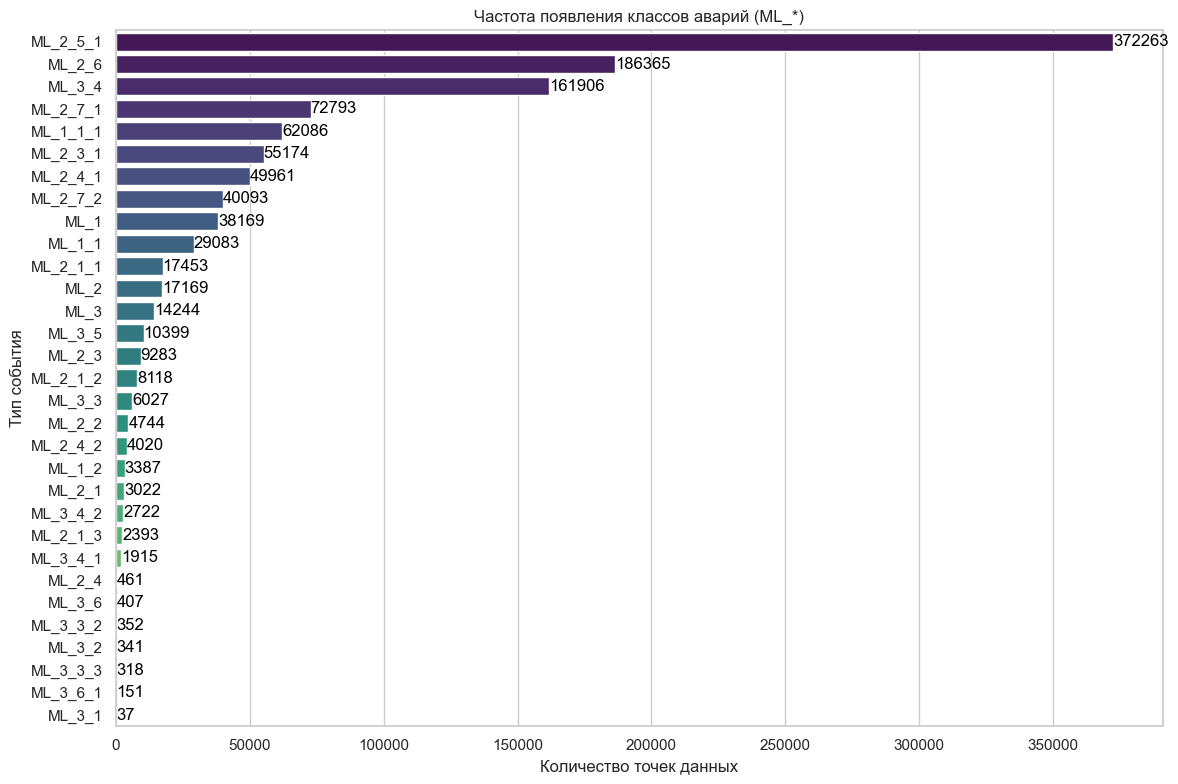


Топ-10 комбинаций классов:
shape: (10, 2)
┌──────────────────────────────┬────────┐
│ combo                        ┆ count  │
│ ---                          ┆ ---    │
│ str                          ┆ u32    │
╞══════════════════════════════╪════════╡
│                              ┆ 598303 │
│ ML_2_5_1                     ┆ 324843 │
│ ML_3_4                       ┆ 160824 │
│ ML_2_6                       ┆ 147249 │
│ ML_1_1_1, ML_2_3_1, ML_2_4_1 ┆ 45255  │
│ ML_1                         ┆ 35901  │
│ ML_2_6, ML_2_7_1             ┆ 20798  │
│ ML_1_1                       ┆ 19272  │
│ ML_2_7_1, ML_2_7_2           ┆ 18863  │
│ ML_2_1_1                     ┆ 17188  │
└──────────────────────────────┴────────┘


In [3]:
# Анализ распределения множественных классов ML (Lazy Polars версия)
if 'lf_meta' in locals():
    ml_classes = [col for col in lf_meta.columns if 'ML_' in col]
    
    if ml_classes:
        print(f"Найдено {len(ml_classes)} классов ML.")
        
        # Lazy вычисления: collect() выполняется только в конце
        print("Подсчет статистики классов...")
        class_counts_df = lf_meta.select(
            [pl.col(c).cast(pl.Float64, strict=False).fill_null(0).sum() for c in ml_classes]
        ).collect()
        
        class_counts = class_counts_df.to_dict(as_series=False)
        
        # Преобразуем в Series
        counts_series = pd.Series({
            k: v[0] if v[0] is not None else 0 
            for k, v in class_counts.items()
        }).sort_values(ascending=False)
        
        plt.figure(figsize=(12, 8))
        sns.barplot(x=counts_series.values, y=counts_series.index, palette='viridis', hue=counts_series.index, legend=False)
        
        for i, v in enumerate(counts_series.values):
            if v > 0:
                plt.text(v + 3, i, str(int(v)), color='black', va='center')
            
        plt.title('Частота появления классов аварий (ML_*)')
        plt.xlabel('Количество точек данных')
        plt.ylabel('Тип события')
        plt.tight_layout()
        plt.show()
        
        # Анализ комбинаций (Lazy)
        if len(ml_classes) > 1:
            print("\nТоп-10 комбинаций классов:")
            combinations = lf_meta.select(
                [pl.col(c).cast(pl.Float64, strict=False).fill_null(0).cast(pl.Int8) for c in ml_classes]
            ).with_columns(
                pl.concat_list(ml_classes).map_elements(
                    lambda row: ', '.join([ml_classes[i] for i, val in enumerate(row) if val == 1]),
                    return_dtype=pl.Utf8
                ).alias('combo')
            ).select('combo').group_by('combo').agg(pl.len().alias('count')).sort('count', descending=True).limit(10).collect()
            
            print(combinations)
    else:
        print("Столбцы с префиксом 'ML_' не найдены.")
else:
    print("Переменная 'lf_meta' не определена.")

## 3. Анализ длительности и частоты дискретизации

C:\Users\Евдаков Алексей\AppData\Local\Temp\ipykernel_22560\657804412.py:4: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  found_cols = [col for col in lf_meta.columns if col.lower() == target_col.lower()]


Используется колонка 'file_name' для идентификации осциллограмм.
Подсчет количества точек (Lazy groupby)...


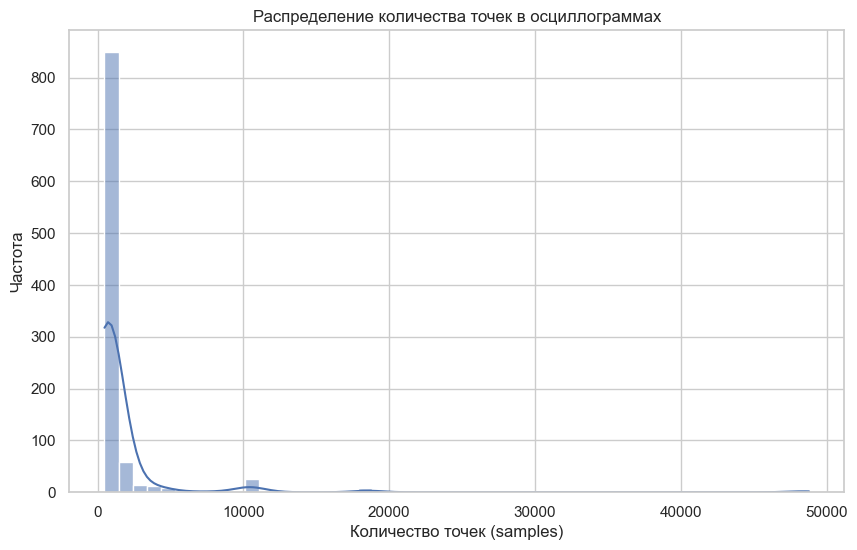

Статистика по точкам:
shape: (1, 8)
┌───────┬─────────────┬─────────────┬─────┬───────┬───────┬───────┬───────┐
│ count ┆ mean        ┆ std         ┆ min ┆ 25%   ┆ 50%   ┆ 75%   ┆ max   │
│ ---   ┆ ---         ┆ ---         ┆ --- ┆ ---   ┆ ---   ┆ ---   ┆ ---   │
│ u32   ┆ f64         ┆ f64         ┆ u32 ┆ f64   ┆ f64   ┆ f64   ┆ u32   │
╞═══════╪═════════════╪═════════════╪═════╪═══════╪═══════╪═══════╪═══════╡
│ 990   ┆ 1570.514141 ┆ 4082.037483 ┆ 468 ┆ 641.0 ┆ 641.0 ┆ 784.0 ┆ 48800 │
└───────┴─────────────┴─────────────┴─────┴───────┴───────┴───────┴───────┘


In [4]:
# Анализ количества точек (длительности) на одну осциллограмму (Lazy Polars версия)
if 'lf_meta' in locals():
    target_col = 'file_name'
    found_cols = [col for col in lf_meta.columns if col.lower() == target_col.lower()]
    
    if found_cols:
        id_col = found_cols[0]
        print(f"Используется колонка '{id_col}' для идентификации осциллограмм.")

        try:
            print("Подсчет количества точек (Lazy groupby)...")
            
            # Lazy groupby оптимизирует выполнение и не требует загрузки всего датасета
            points_per_osc = lf_meta.group_by(id_col).agg(pl.len().alias('count')).select('count').collect()
            points_array = points_per_osc['count'].to_numpy()
            
            plt.figure(figsize=(10, 6))
            sns.histplot(points_array, bins=50, kde=True)
            plt.title('Распределение количества точек в осциллограммах')
            plt.xlabel('Количество точек (samples)')
            plt.ylabel('Частота')
            plt.show()
            
            stats_df = points_per_osc.select(
                [
                    pl.col('count').count().alias('count'),
                    pl.col('count').mean().alias('mean'),
                    pl.col('count').std().alias('std'),
                    pl.col('count').min().alias('min'),
                    pl.col('count').quantile(0.25).alias('25%'),
                    pl.col('count').median().alias('50%'),
                    pl.col('count').quantile(0.75).alias('75%'),
                    pl.col('count').max().alias('max')
                ]
            )
            print(f"Статистика по точкам:\n{stats_df}")
            
        except Exception as e:
            print(f"Ошибка при подсчете: {e}")
            
    else:
        print(f"Колонка '{target_col}' не найдена.")
else:
    print("Переменная 'lf_meta' не определена.")

## 4. Визуализация сигналов

Загрузим несколько случайных файлов и отобразим их.

C:\Users\Евдаков Алексей\AppData\Local\Temp\ipykernel_22560\2660495377.py:4: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  found_cols = [col for col in lf_meta.columns if col.lower() == target_col.lower()]
C:\Users\Евдаков Алексей\AppData\Local\Temp\ipykernel_22560\2660495377.py:17: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  current_cols = [col for col in lf_meta.columns if any(p in col for p in ['IA', 'IB', 'IC'])]
C:\Users\Евдаков Алексей\AppData\Local\Temp\ipykernel_22560\2660495377.py:18: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operati

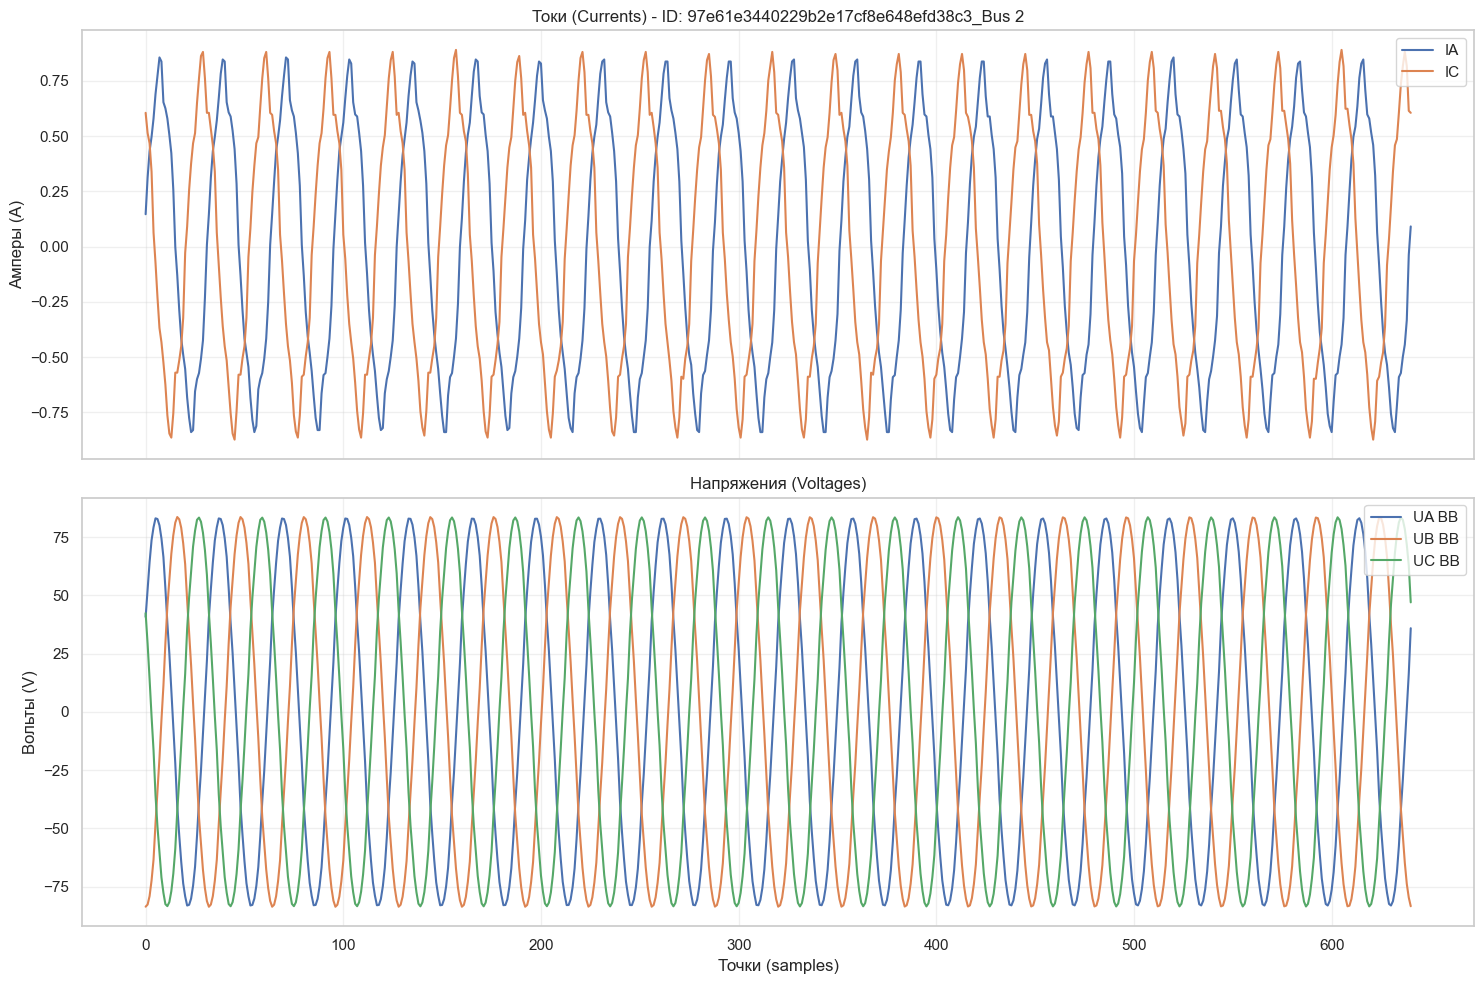

C:\Users\Евдаков Алексей\AppData\Local\Temp\ipykernel_22560\2660495377.py:69: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  ml_cols = [col for col in lf_meta.columns if 'ML_' in col]
C:\Users\Евдаков Алексей\AppData\Local\Temp\ipykernel_22560\2660495377.py:71: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ml_data = osc_pandas[ml_cols].fillna(0).astype(float)


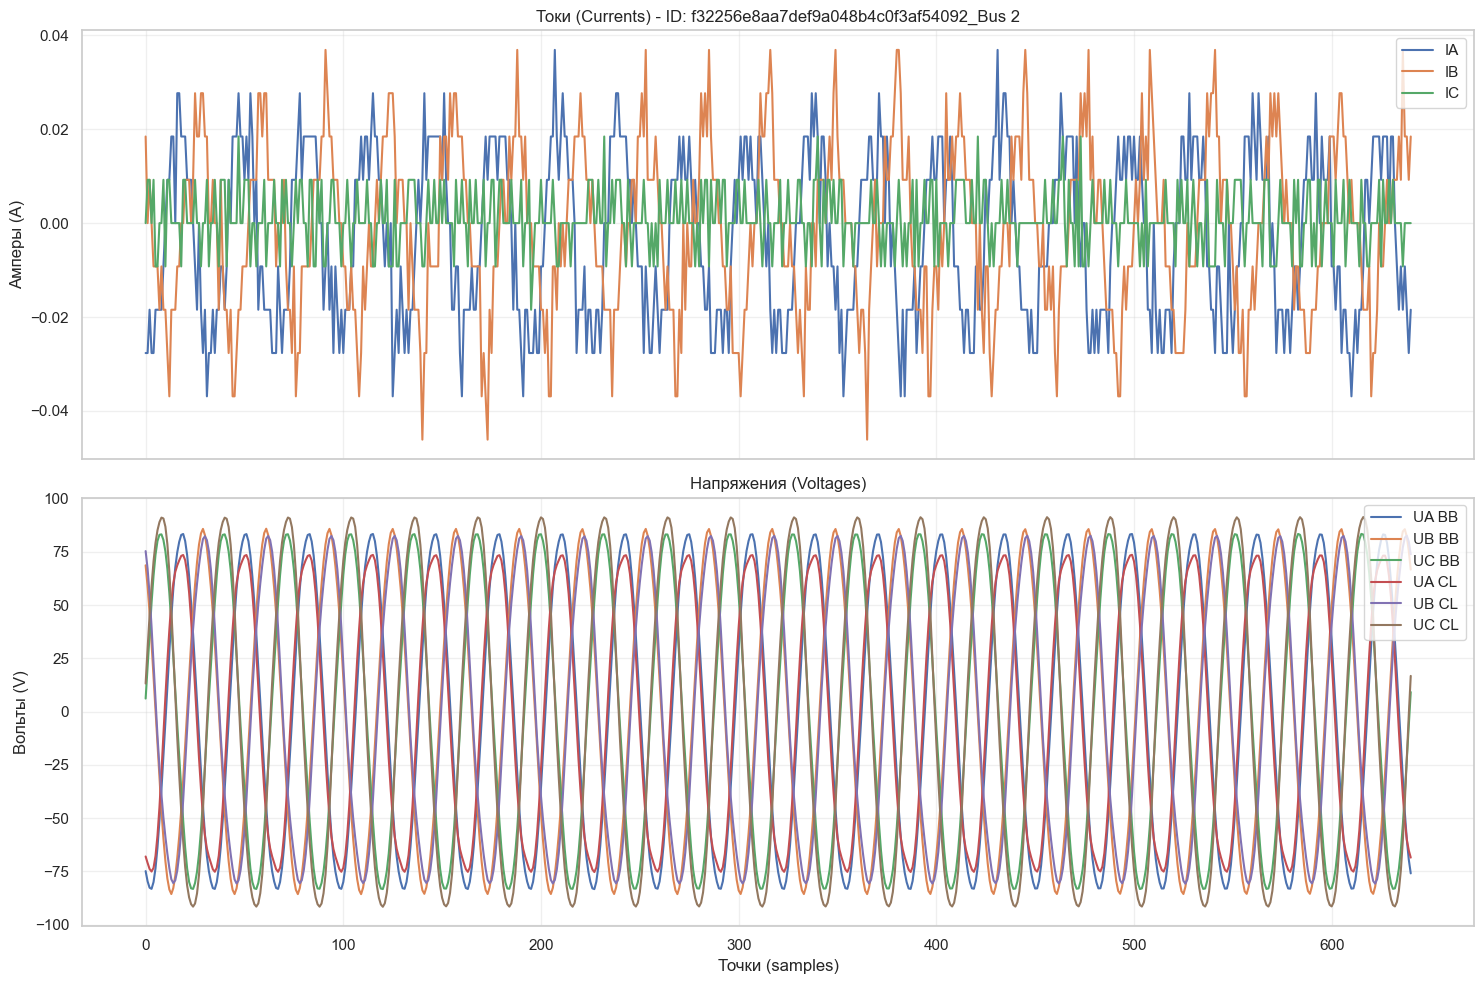

C:\Users\Евдаков Алексей\AppData\Local\Temp\ipykernel_22560\2660495377.py:69: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  ml_cols = [col for col in lf_meta.columns if 'ML_' in col]
C:\Users\Евдаков Алексей\AppData\Local\Temp\ipykernel_22560\2660495377.py:71: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ml_data = osc_pandas[ml_cols].fillna(0).astype(float)


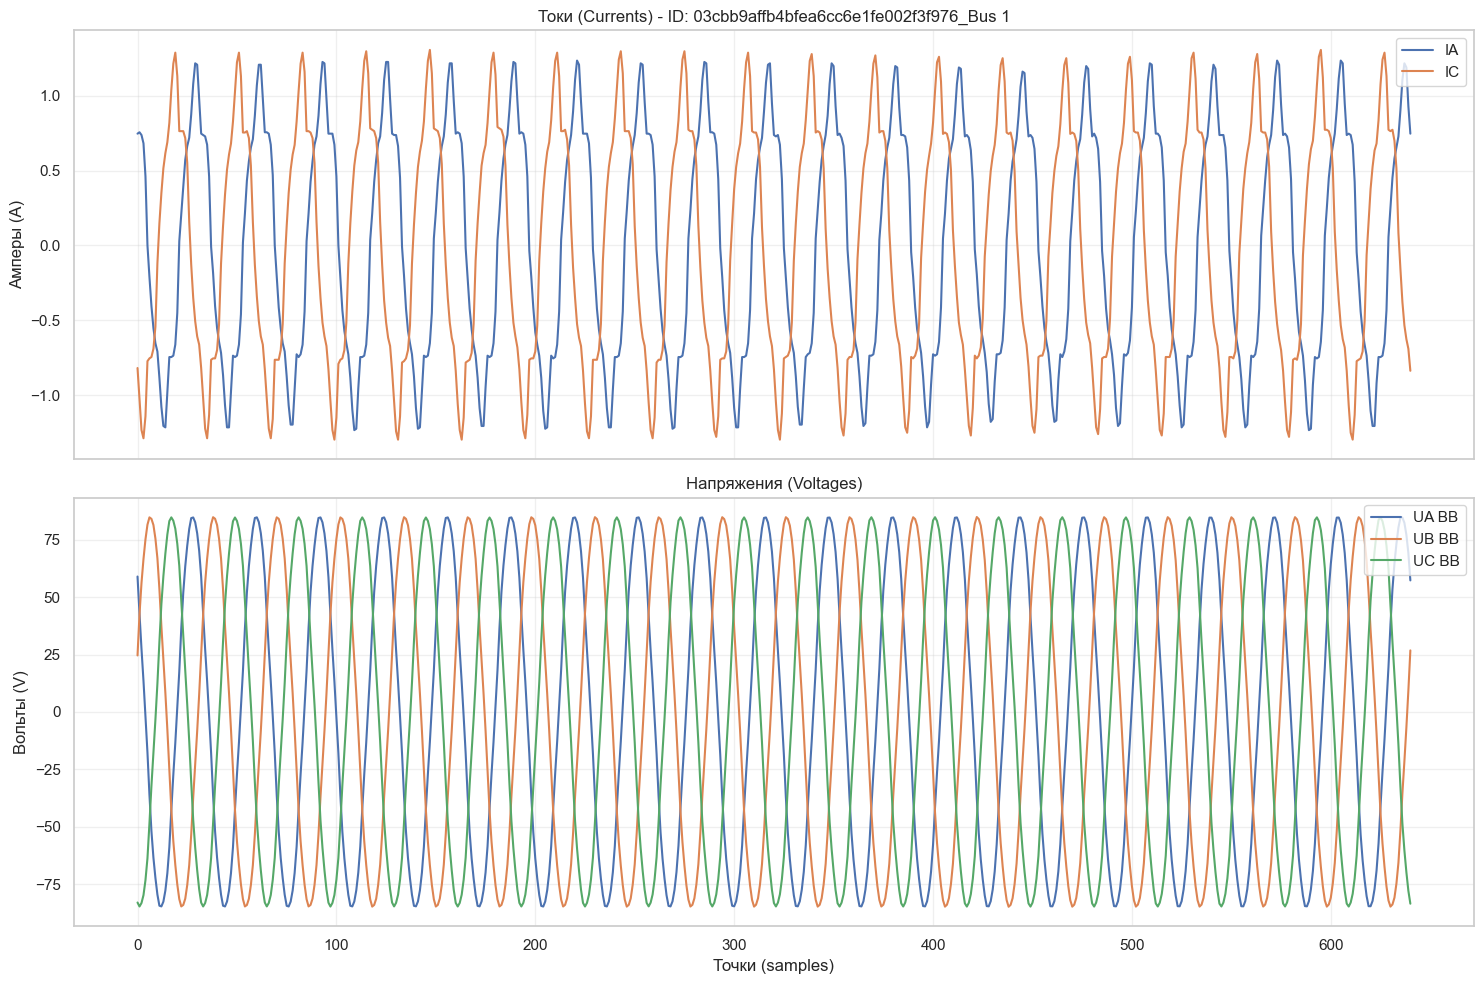

In [6]:
# Визуализация случайных осциллограмм (Lazy Polars версия)
if 'lf_meta' in locals():
    target_col = 'file_name'
    found_cols = [col for col in lf_meta.columns if col.lower() == target_col.lower()]
    
    if found_cols:
        id_col = found_cols[0]
        
        try:
            # Получаем уникальные ID (Lazy unique)
            unique_ids = lf_meta.select(id_col).unique().collect()[id_col].to_list()
            
            if len(unique_ids) > 0:
                sample_ids = np.random.choice(unique_ids, size=min(3, len(unique_ids)), replace=False)
                
                # Определяем колонки токов и напряжений
                current_cols = [col for col in lf_meta.columns if any(p in col for p in ['IA', 'IB', 'IC'])]
                voltage_cols = [col for col in lf_meta.columns if any(p in col for p in ['UA', 'UB', 'UC'])]
                
                # Если стандартные имена не найдены, берем числовые колонки
                if not current_cols and not voltage_cols:
                    candidates = [c for c in lf_meta.columns if c != id_col and 'ML_' not in c][:10]
                    schema = lf_meta.schema
                    numeric_cols = [c for c in candidates if schema[c] in [pl.Float64, pl.Int64, pl.Float32, pl.Int32]]
                    # Просто делим пополам для примера
                    mid = len(numeric_cols) // 2
                    current_cols = numeric_cols[:mid]
                    voltage_cols = numeric_cols[mid:]

                for osc_id in sample_ids:
                    # Lazy filter + collect
                    osc_data = lf_meta.filter(pl.col(id_col) == osc_id).collect()
                    
                    if len(osc_data) == 0:
                        continue
                    
                    # Собираем все нужные колонки
                    all_signal_cols = current_cols + voltage_cols
                    osc_pandas = osc_data.select(
                        [pl.col(c).cast(pl.Float64, strict=False) for c in all_signal_cols if c in osc_data.columns] +
                        [pl.col(c) for c in osc_data.columns if c not in all_signal_cols]
                    ).to_pandas()
                    
                    # Создаем сабплоты: сверху токи, снизу напряжения
                    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
                    
                    # Рисуем токи
                    for col in current_cols:
                        if col in osc_pandas.columns:
                            if not osc_pandas[col].isna().all():
                                ax1.plot(osc_pandas[col], label=col)
                    ax1.set_title(f"Токи (Currents) - ID: {osc_id}")
                    ax1.set_ylabel("Амперы (A)")
                    ax1.legend(loc='upper right')
                    ax1.grid(True, alpha=0.3)
                    
                    # Рисуем напряжения
                    for col in voltage_cols:
                        if col in osc_pandas.columns:
                            if not osc_pandas[col].isna().all():
                                ax2.plot(osc_pandas[col], label=col)
                    ax2.set_title(f"Напряжения (Voltages)")
                    ax2.set_ylabel("Вольты (V)")
                    ax2.set_xlabel("Точки (samples)")
                    ax2.legend(loc='upper right')
                    ax2.grid(True, alpha=0.3)
                    
                    # Накладываем ML разметку на оба графика
                    ml_cols = [col for col in lf_meta.columns if 'ML_' in col]
                    if ml_cols:
                        ml_data = osc_pandas[ml_cols].fillna(0).astype(float)
                        active_ml = (ml_data.sum(axis=1) > 0).values
                        if active_ml.any():
                            for ax in [ax1, ax2]:
                                ax.fill_between(range(len(osc_pandas)), ax.get_ylim()[0], ax.get_ylim()[1], 
                                                 where=active_ml, color='red', alpha=0.1, label='ML Event')

                    plt.tight_layout()
                    plt.show()
            else:
                print("Нет уникальных ID.")
        except Exception as e:
             print(f"Ошибка при визуализации: {e}")
             import traceback
             traceback.print_exc()
    else:
        print("Колонка ID не найдена.")
else:
    print("Переменная 'lf_meta' не определена.")